# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Gonzales, Naeumi
- _Student No._: 2024-11022
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Problem 1: Hamiltonian Matrix and its Eigs
![First 5 Eigenstates of the Quantum Harmonic Oscillator](QHO_5eigenstates.png)

Figure 1. First 5 Eigenstates of the Quantum Harmonic Oscillator

To form the Hamiltonian matrix, the kinetic energy operator was discretized using a central finite-difference scheme, while the harmonic potential $V(x)$ was represented as a diagonal matrix. Solving the eigenvalue system $H\psi = E\psi$ via np.linalg.eigh over a 100-point grid yielded discrete, evenly spaced energy levels ($\Delta E \approx \hbar\omega = 0.8$). The ground-state zero-point energy was found to be $E_0 = 0.40$, increasing sequentially up to $E_4 = 3.59$ for the fifth state. Plotting the eigenfunctions with vertical offsets ($f_n = \psi_n + E_n$) reveals that the $n$-th state contains precisely $n$ spatial nodes. Additionally, the wavefunctions penetrate past the classical turning points of $V(x) = \frac{1}{2}m\omega^2x^2$ prior to decaying exponentially, demonstrating quantum tunneling in the classically forbidden zones.

### Problem 2: Harmonic Oscillator in an Electric Field
![Numerical vs Theoretical Eigenenergies (100 States)](num_theo_eigenenergies.png)

Figure 2. Numerical vs Theoretical Eigenenergies (100 States)

![Potential and Ground State Probability of the Ground State](probdenstity.png)

Figure 3. Potential and Ground State Probability of the Ground State

Figure 2 indicates strong agreement between the matrix-derived numerical eigenenergies and theoretical expectations for lower quantum states ($n \le 30$). Beyond this threshold, the numerical eigenvalues systematically exceed theoretical values. This divergence arises because high-energy states feature rapid oscillations and broader spatial extent; the finite grid boundaries ($x \in [-10, 10]$) impose hard boundary conditions that artificially confine these broad wavefunctions, elevating their energy levels. 

Moreover, Figure 3 confirms the physically expected ground-state response. Applying a uniform electric field adds a linear $qEx$ perturbation, displacing the harmonic potential minimum toward negative $x$ and decreasing the potential baseline. The resulting ground-state probability density ($\vert{}\psi_0(x)\vert{}^2$) preserves its characteristic Gaussian distribution while centering directly above the relocated potential minimum $V(x)$.

### Other comments
- None


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + E_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [21]:
import numpy as np
import matplotlib.pyplot as plt

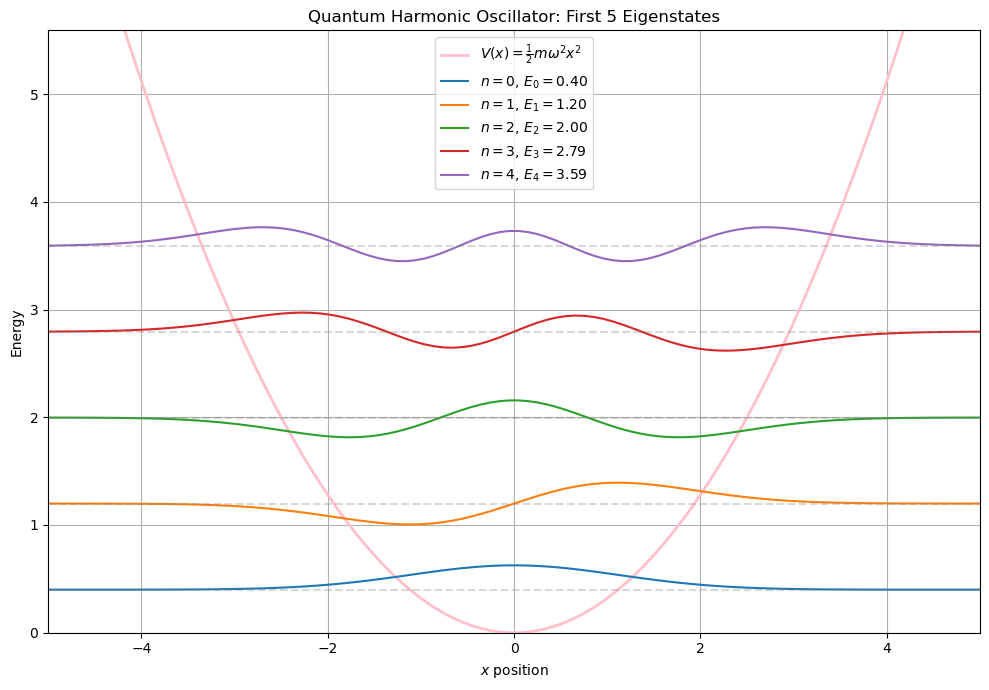

In [22]:
def hamiltonian(x_pos, potential_array, mass, hbar):
    """Constructs the discrete Hamiltonian matrix H = T + V for a 1D system using finite differences."""
    N = len(x_pos)
    dx = x_pos[1] - x_pos[2] # Grid spacing (fixed x_pos[1] - x_pos[0] to ensure a positive dx)

    # Construct second derivative matrix
    diag = -2 * np.eye(N) 
    off_diag = np.eye(N, k=-1) + np.eye(N, k=1) # Off-diagonals (+1 above and below)
    second_der = (diag + off_diag)/(dx**2)

    # Kinetic energy matrix operator
    T = - ((hbar**2)/(2*m))*(second_der)
    
    # Potential energy matrix operator
    V = np.diag(potential_array)

    # Total Hamiltonian operator
    return T + V

# Parameters
m = 1
hbar = 1
w = 0.8
N_points = 100
x = np.linspace(-5, 5, N_points)
dx = x[1] - x[0]

# Define harmonic oscillator potential:
V_x = (0.5)*(m)*(w**2)*(x**2)

# Build Hamiltonian matrix
H = hamiltonian(x, V_x, m, hbar)

# Solve the time-independent Schrödinger equation
eigenvalues, eigenvectors = np.linalg.eigh(H)

plt.figure(figsize=(10, 7))

# Plot the potential energy well V(x)
plt.plot(x, V_x, color="pink", linewidth=2, label=r'$V(x) = \frac{1}{2}m\omega^2 x^2$')

# Plot the first 5 energy eigenstates
for n in range(5):
    E_n = eigenvalues[n] # n-th energy eigenvalue
    psi_n = eigenvectors[:, n] # n-th energy eigenvector (wavefunction)

    # Shift wavefunction vertically by its energy level
    f_n = psi_n + E_n

    plt.plot(x, f_n, label=f'$n={n}$, $E_{n}={E_n:.2f}$')
    plt.axhline(E_n, color='gray', linestyle='--', alpha=0.3)

plt.ylim(0, eigenvalues[4] + 2)
plt.xlim(-5, 5)
plt.xlabel('$x$ position')
plt.ylabel('Energy')
plt.title('Quantum Harmonic Oscillator: First 5 Eigenstates')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('QHO_5eigenstates.png')
plt.show()


#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
* Across an $N=100$ grid, discretization of space was performed in this code to solve the time-independent Schrödinger equation for a quantum harmonic oscillator. The combination of a finite-difference matrix and a diagonal potential matrix $V(x)$ was utilized to create the kinetic energy operator, which permits np.linalg.eigh() to solve the matrix eigenvalue problem $H\psi = E\psi$. Node counts and quantum tunneling at each state were demonstrated by plotting each eigenfunction vertically offset by its energy eigenvalue ($f_n = \psi_n + E_n$) along with $V(x)$.

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
E_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

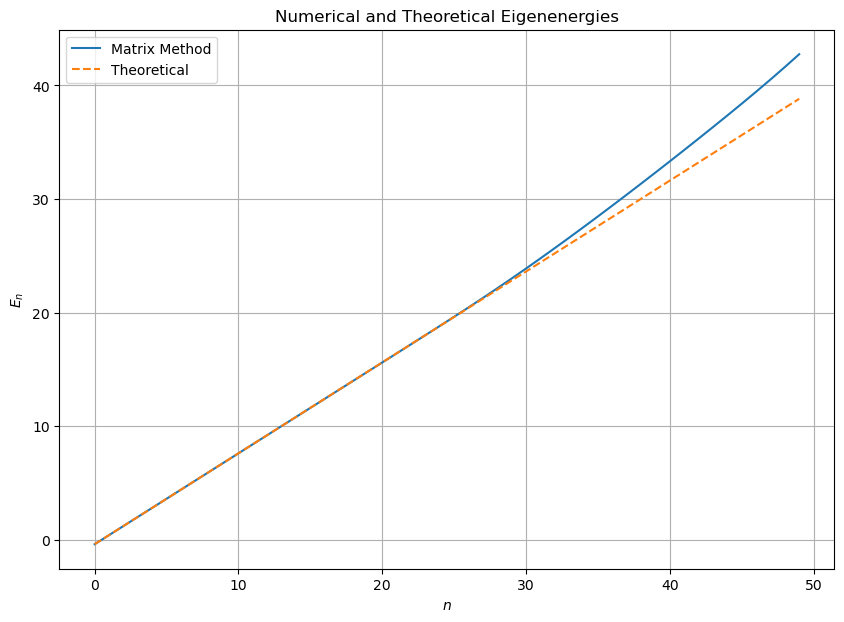

In [26]:
# Parameters
qE = 1 # E = q^-1, q*E = +1
N_points = 1001 # Number of spatial grid points
x = np.linspace(-10, 10, N_points) # Spatial domain spanning from -10 to 10
dx = x[1] - x[0] # Grid spacing

# Array of the first 50 numerically calculated eigenvalues
hundred_E = eigenvalues[:50]
hundred_n = np.arange(50)

# Analytical energy eigenvalues
E_n = hbar*w*(hundred_n+0.5)-(qE**2) / ((2*m)*(w**2))

# Potential energy function V(x)
potential = (0.5)*(m)*(w**2)*(x**2) + qE*x

# Construct total Hamiltonian matrix with the perturbed potential
H = hamiltonian(x, potential, m, hbar)

# Solve matrix eigenvalue problem
eigenvalues, eigenvectors = np.linalg.eigh(H)

plt.figure(figsize=(10, 7))
plt.plot(hundred_n, hundred_E, label="Matrix Method") # Plot numerical eigenenergies
plt.plot(hundred_n, E_n, label="Theoretical", linestyle='--') # Plot exact analytical eigenenergies

plt.xlabel("$n$")
plt.ylabel("$E_n$")
plt.title("Numerical and Theoretical Eigenenergies")
plt.legend()
plt.savefig('num_theo_eigenenergies.png')
plt.grid()

Total Probability Density: 1.000000


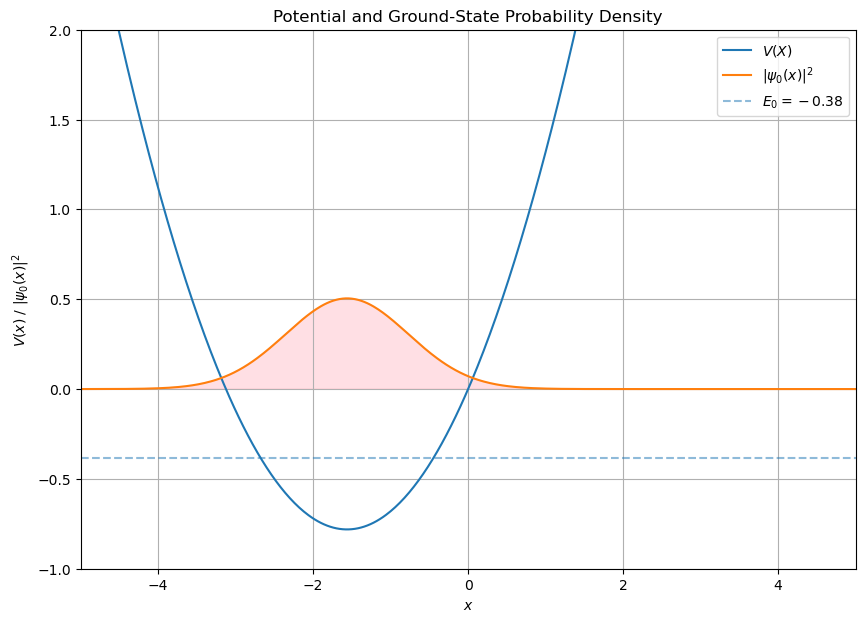

In [27]:
# 1. Extract raw, unnormalized eigenvector from the matrix solution
psi_raw = eigenvectors[:, 0]
norm_sq = np.trapz(np.abs(psi_raw)**2, x)
psi_0 = psi_raw / np.sqrt(norm_sq)
prob_density = np.abs(psi_0)**2 
E_0 = eigenvalues[0]

# 4. Calculates the probability density
total_prob = np.trapz(prob_density, x)
print(f"Total Probability Density: {total_prob:.6f}")

# 5. Confirms the integral is equal to 1.0
plt.figure(figsize=(10, 7))
plt.plot(x, potential, label="$V(X)$")
plt.plot(x, prob_density, label=r"$|\psi_0(x)|^2$")
plt.fill_between(x, prob_density, color="pink", alpha=0.5)
plt.axhline(E_0, linestyle="--", alpha=0.5, label=f"$E_0 = {E_0:.2f}$")

plt.ylim(-1, 2)
plt.xlim(-5, 5)

plt.xlabel("$x$")
plt.ylabel("$V(x)$ / $|\psi_0(x)|^2$")
plt.title("Potential and Ground-State Probability Density")
plt.legend()
plt.grid()
plt.savefig('probdenstity.png')
plt.show()


#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
* Evaluation of a quantum harmonic oscillator's energy levels and ground-state wavefunction in a uniform electric field through a spatial grid ($N=1000$) is done in the code. Comparison between the numerical eigenenergies and theoretical values is performed through solving the matrix Hamiltonian by utilizing np.linalg.eigh(). Plotting the centered probability density $\vert{}\psi_0(x)\vert{}^2$ over the displaced potential minimum was executed by explicitly normalizing the raw ground-state eigenvector through trapezoidal integration (np.trapz).

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)